In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [3]:
# %% 1. Prepare reusable plotting data: saved MMM maps and model-balanced spreads
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def overview_member_spread(member_values, model_names, central_fraction=.8):
    """Equal total probability per model, divided equally among its valid members.

    Returns observed-value percentile endpoints (inverse empirical CDF), not a
    confidence interval on the MMM. Single-member models retain one model vote.
    """
    if not 0 < central_fraction < 1:
        raise ValueError("central_fraction must be between zero and one.")
    members = [np.asarray(member_values[m], dtype=float) for m in model_names]
    if not members or any(v.ndim != 2 or not len(v) or v.shape[1] != members[0].shape[1] for v in members):
        raise ValueError("Expected nonempty (member,start_year) arrays for each model.")
    n_years = members[0].shape[1]
    probabilities = np.array([(1-central_fraction)/2, (1+central_fraction)/2])
    bounds, full_range, mean = np.full((2, n_years), np.nan), np.full((2, n_years), np.nan), np.full(n_years, np.nan)
    n_models, n_members = np.zeros(n_years, dtype=int), np.zeros(n_years, dtype=int)
    # Windows are summarized separately; they are not counted as independent members.
    for s in range(n_years):
        valid_members = [v[:, s][np.isfinite(v[:, s])] for v in members]
        valid_members = [v for v in valid_members if len(v)]
        if not valid_members:
            continue
        values = np.concatenate(valid_members)
        weights = np.concatenate([np.full(len(v), 1/(len(valid_members)*len(v))) for v in valid_members])
        order = np.argsort(values)
        values, weights = values[order], weights[order]
        cumulative = np.cumsum(weights)
        cumulative /= cumulative[-1]
        positions = np.searchsorted(cumulative, np.maximum(0., probabilities-8*np.finfo(float).eps), side="left")
        bounds[:, s] = values[np.minimum(positions, len(values)-1)]
        full_range[:, s] = [values[0], values[-1]]
        mean[s] = np.mean([v.mean() for v in valid_members])
        n_models[s], n_members[s] = len(valid_members), len(values)
    return {"lower": bounds[0], "upper": bounds[1], "minimum": full_range[0], "maximum": full_range[1],
            "MMM": mean, "n_models": n_models, "n_members": n_members, "central_fraction": central_fraction}


def prepare_region_overview(catalog, series_archive, directory, *, experiment="amip_hist",
                            central_fraction=.8, receiving_mask=None, receiving_label="Global"):
    """Read four MMM bundles once; keep only fields needed to browse many years.

    Column 2's scalar is the spatial mean of cov_A_Zi over ONE common receiving
    domain, not the SD of A and not the original radiation index I. A supplied
    mask changes only this scalar reduction, not the source regions or maps.
    """
    if catalog["signature"] != series_archive["signature"]:
        raise ValueError("Catalog and compact series come from different numerical runs.")
    names = list(catalog["model_names"][experiment])
    if names != list(series_archive["model_names"][experiment]):
        raise ValueError("Catalog and compact series use different model populations.")
    years = np.asarray(catalog["coordinates"]["start_year"])
    lat, lon = [np.asarray(catalog["coordinates"][d]) for d in ["lat", "lon"]]
    weights = np.asarray(catalog["weights"], dtype=float)
    shape = (len(years), len(lat), len(lon))
    if weights.shape != shape[1:] or np.any(weights < 0) or not np.isfinite(weights).all():
        raise ValueError("Expected finite nonnegative grid weights.")
    support = weights > 0
    if not support.any():
        raise ValueError("No positive-weight cells.")
    weights = weights/weights.sum()
    requested_support = support.copy()
    if receiving_mask is not None:
        mask = np.ma.asarray(receiving_mask, dtype=float).filled(np.nan)
        if mask.shape != weights.shape:
            raise ValueError("receiving_mask must have (lat,lon) shape.")
        requested_support &= np.isfinite(mask) & (mask != 0)
    if not requested_support.any():
        raise ValueError("Empty receiving domain for the middle time series.")
    fractions = {r: float(catalog["SEP_area_fractions"][r]) for r in ["SEPn", "SEPs"]}
    if any(not np.isfinite(f) or f <= 0 for f in fractions.values()) or not np.isclose(sum(fractions.values()), 1):
        raise ValueError("Invalid north/south source area fractions.")

    # Keep ~8 running fields, rather than all quantities from four large bundles.
    # Once this cache exists, changing only start_year requires no further file I/O.
    maps, indices = {}, {}
    common_support = requested_support.copy()
    for region in ["SEP", "SEPn", "SEPs", "WPWP"]:
        bundle = np.load(Path(directory)/catalog["MMM_files"][region][experiment], allow_pickle=True).item()
        if "labels" in bundle and list(bundle["labels"]) != names:
            raise ValueError(f"{region}: MMM model labels differ from the catalog.")
        values = bundle["values"]
        D = np.asarray(values["D"], dtype=float)
        if D.shape != shape or not np.isfinite(D[:, support]).all():
            raise ValueError(f"{region}: incomplete D maps on the global weighted domain.")
        maps[region] = {"D": D}
        indices[region] = np.asarray(series_archive["MMM_values"][region][experiment]["I"], dtype=float)
        if indices[region].shape != (len(years),) or not np.isfinite(indices[region]).all():
            raise ValueError(f"{region}: expected one finite index value per start year.")
        np.testing.assert_allclose(np.sum(D[:, support]*weights[support], axis=1), indices[region], rtol=1e-8, atol=1e-10,
                                   err_msg=f"{region}: the global D mean does not match the saved I")
        if region != "WPWP":
            C = np.asarray(values["cov_A_Zi"], dtype=float)
            if C.shape != shape:
                raise ValueError(f"{region}: inconsistent cov_A_Zi shape.")
            maps[region]["cov_A_Zi"] = C
            common_support &= np.isfinite(C).all(axis=0)
        if region == "SEP":
            maps[region]["cov_Zi_R"] = np.asarray(values["cov_Zi_R"], dtype=float)
            if maps[region]["cov_Zi_R"].shape != shape:
                raise ValueError("cov_Zi_R shape differs from the grid/windows.")
        del bundle, values

    # Use exactly the same receiving cells/weights in every window and source.
    # Constant-T cells can make standardized covariances undefined: retain their
    # NaNs on maps, exclude them from this fixed common receiving average, and
    # explicitly report the retained fraction of the requested spatial domain.
    if not common_support.any():
        raise ValueError("No common finite receiving cells for the cov_A_Zi time series.")
    receiving_weights = np.where(common_support, weights, 0.)
    receiving_weights /= receiving_weights.sum()
    covariance_series = {r: np.sum(maps[r]["cov_A_Zi"][:, common_support]*receiving_weights[common_support], axis=1)
                         for r in ["SEP", "SEPn", "SEPs"]}
    coverage = float(weights[common_support].sum()/weights[requested_support].sum())
    # These are linear mixtures of source indices. Correlation/slope fits are
    # not being combined; they would have different predictors/normalizations.
    for key in ["D", "cov_A_Zi"]:
        combined = sum(fractions[r]*maps[r][key] for r in fractions)
        np.testing.assert_allclose(combined, maps["SEP"][key], rtol=1e-8, atol=1e-10, equal_nan=True,
                                   err_msg=f"North/south {key} maps do not reconstruct SEP")
    np.testing.assert_allclose(sum(fractions[r]*indices[r] for r in fractions), indices["SEP"], rtol=1e-8, atol=1e-10)
    np.testing.assert_allclose(sum(fractions[r]*covariance_series[r] for r in fractions), covariance_series["SEP"], rtol=1e-8, atol=1e-10)
    spread = {}
    for region in ["SEP", "WPWP"]:
        member_values = series_archive["member_values"][region][experiment]["I"]
        spread[region] = overview_member_spread(member_values, names, central_fraction)
        np.testing.assert_allclose(spread[region]["MMM"], indices[region], rtol=1e-8, atol=1e-10,
                                   err_msg=f"{region}: saved MMM differs from equal-model member mean")
    return {"experiment": experiment, "years": years, "lat": lat, "lon": lon, "maps": maps,
            "indices": indices, "covariance_series": covariance_series, "spread": spread, "fractions": fractions,
            "regions": catalog["regions"], "weights": weights, "receiving_weights": receiving_weights,
            "receiving_label": receiving_label, "receiving_coverage": coverage, "central_fraction": central_fraction}




In [4]:
# %% 2. The 4 x 3 map/time-series layout
def plot_region_overview(data, *, start_year=1980, D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2,
                         central_longitude=210, cmap="RdBu_r", show_full_member_range=False,
                         line_ylims=None, coastlines=True, figsize=(17.5, 14.5), savepath=None):
    """North/south maps and curves are AREA-WEIGHTED contributions to full SEP.

    Columns: D decomposition; cov_A_Zi decomposition; cov_Zi_R/SEP D/WPWP D.
    Bottom: global D means; receiving-domain cov_A_Zi means; SEP/WPWP indices
    with a model-balanced member spread (not a CI). Year selection is visual only.
    """
    years = data["years"]
    matches = np.flatnonzero(years == start_year)
    if len(matches) != 1:
        raise ValueError(f"Start year {start_year} is not present in the saved archive.")
    s = matches[0]
    f_n, f_s = data["fractions"]["SEPn"], data["fractions"]["SEPs"]
    maps = data["maps"]
    # The repeated full SEP D map uses the SAME array, normalization and scale.
    fields = [[maps["SEP"]["D"][s], maps["SEP"]["cov_A_Zi"][s], maps["SEP"]["cov_Zi_R"][s]],
              [f_n*maps["SEPn"]["D"][s], f_n*maps["SEPn"]["cov_A_Zi"][s], maps["SEP"]["D"][s]],
              [f_s*maps["SEPs"]["D"][s], f_s*maps["SEPs"]["cov_A_Zi"][s], maps["WPWP"]["D"][s]]]
    titles = [["Full SEP: D", "Full SEP: cov(A, Zi)", "Temperature-origin: cov(Zi, Rg)"],
              [f"SEPn contribution: {f_n:.1%} × D_n", f"SEPn contribution: {f_n:.1%} × cov(A_n, Zi)", "Full SEP: D"],
              [f"SEPs contribution: {f_s:.1%} × D_s", f"SEPs contribution: {f_s:.1%} × cov(A_s, Zi)", "Full WPWP: D"]]
    outlines = [["SEP", "SEP", "SEP"], ["SEPn", "SEPn", "SEP"], ["SEPs", "SEPs", "WPWP"]]
    # Fixed limits are the default so figures for different years are comparable.
    # None requests a 98th-percentile limit for that quantity in THIS figure.
    def limit(value, selected):
        finite = np.concatenate([np.abs(v[np.isfinite(v)]) for v in selected])
        if value is None:
            value = max(float(np.percentile(finite, 98)), 1e-12) if finite.size else 1.
        value = float(value)
        if not np.isfinite(value) or value <= 0:
            raise ValueError("Color limits must be positive finite numbers or None.")
        return value
    dlim = limit(D_vlim, [fields[r][0] for r in range(3)]+[fields[1][2], fields[2][2]])
    clim = limit(C_vlim, [fields[r][1] for r in range(3)])
    zlim = limit(ZiR_vlim, [fields[0][2]])
    limits = [[dlim, clim, zlim], [dlim, clim, dlim], [dlim, clim, dlim]]
    fig = plt.figure(figsize=figsize)
    # Dedicated colorbar rows prevent Cartopy's fixed map aspect from squeezing
    # labels into neighboring panels. Empty colorbar slots maintain alignment.
    grid = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1.03], left=.05, right=.985,
                           bottom=.09, top=.92, wspace=.20, hspace=.27)
    axes = np.empty((4, 3), dtype=object)
    colorbars = []
    for row in range(3):
        for col in range(3):
            slot = grid[row, col].subgridspec(2, 1, height_ratios=[1, .065], hspace=.10)
            ax = fig.add_subplot(slot[0], projection=ccrs.Robinson(central_longitude=central_longitude))
            axes[row, col] = ax
            field, lon = add_cyclic_point(fields[row][col], coord=data["lon"], axis=-1)
            im = ax.pcolormesh(lon, data["lat"], field, cmap=cmap, vmin=-limits[row][col], vmax=limits[row][col],
                               shading="auto", transform=ccrs.PlateCarree())
            mask, _ = add_cyclic_point(np.asarray(data["regions"][outlines[row][col]], dtype=float), coord=data["lon"])
            ax.contour(lon, data["lat"], mask, levels=[.5], colors="black", linewidths=.85, transform=ccrs.PlateCarree())
            if coastlines:
                ax.coastlines(linewidth=.5, color=".25")
            ax.set_global()
            ax.set_title(f"({chr(97+3*row+col)}) {titles[row][col]}", fontsize=10.5, pad=6)
            # Shared first/middle column scales; a separate top-right covariance
            # bar and a bottom-right D bar (same D limits as the first column).
            if row == 2 or (row == 0 and col == 2):
                cax = fig.add_subplot(slot[1])
                bar = fig.colorbar(im, cax=cax, orientation="horizontal", extend="both")
                bar.set_label("cov(A, Zi) [dimensionless]" if col == 1 else "cov(Zi, Rg) [W m⁻²]" if row == 0 else "D [W m⁻²]", fontsize=9)
                bar.ax.tick_params(labelsize=8)
                colorbars.append(bar)

    # The first two columns have additive north/south source contributions.
    # Column 2 reduces its MMM maps over one fixed receiving domain; it is NOT
    # a new covariance calculated from ensemble-averaged monthly fields.
    north_color, south_color = "#0072B2", "#D55E00"
    for col, series in enumerate([data["indices"], data["covariance_series"]]):
        ax = fig.add_subplot(grid[3, col], sharex=axes[3, 0] if col else None)
        axes[3, col] = ax
        ax.plot(years, series["SEP"], color="black", lw=2.3, label="Full SEP", zorder=4)
        ax.plot(years, f_n*series["SEPn"], color=north_color, lw=1.8, label="SEPn contribution")
        ax.plot(years, f_s*series["SEPs"], color=south_color, lw=1.8, label="SEPs contribution")
        ax.legend(frameon=False, fontsize=8, loc="best")
    axes[3, 0].set(title="(j) SEP index decomposition", ylabel="I [W m⁻²]")
    axes[3, 1].set(title=f"(k) {data['receiving_label']} mean of cov(A, Zi)", ylabel="Area-mean covariance [dimensionless]")

    ax = fig.add_subplot(grid[3, 2], sharex=axes[3, 0])
    axes[3, 2] = ax
    for region, color in [("SEP", "#0072B2"), ("WPWP", "#D55E00")]:
        spread = data["spread"][region]
        if show_full_member_range:
            ax.fill_between(years, spread["minimum"], spread["maximum"], color=color, alpha=.06, linewidth=0)
        ax.fill_between(years, spread["lower"], spread["upper"], color=color, alpha=.18, linewidth=0)
        ax.plot(years, data["indices"][region], color=color, lw=2.2, label=region)
    ax.set(title="(l) SEP versus WPWP", ylabel="I = global area mean of D [W m⁻²]")
    ax.legend(frameon=False, fontsize=9, loc="best")
    if line_ylims is not None and len(line_ylims) != 3:
        raise ValueError("line_ylims must have three entries, each None or (low,high).")
    for col, ax in enumerate(axes[3]):
        ax.axhline(0, color=".5", lw=.65, zorder=0)
        ax.axvline(start_year, color=".2", ls="--", lw=1.2, zorder=5)
        ax.set(xlabel="Window start year (March)", xlim=(years[0], years[-1]))
        if line_ylims is not None and line_ylims[col] is not None:
            ax.set_ylim(line_ylims[col])
        ax.grid(alpha=.18)
        ax.tick_params(labelsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    name = {"amip_hist": "AMIP-hist", "historical_matched": "Historical: matched", "historical": "Historical: all"}[data["experiment"]]
    fig.suptitle(f"{name} — regional attribution, window starting March {start_year}\nEqual-model MMMs of member diagnostics; northern/southern panels are area-weighted contributions", fontsize=14, y=.977)
    spread_note = f"Right shading: model-balanced central {100*data['central_fraction']:g}% member spread, not a confidence interval."
    if show_full_member_range:
        spread_note += " Faint outer shading: full member range."
    fig.text(.05, .025, f"Dashed lines mark {start_year}. {spread_note}\nMiddle series uses a fixed common receiving domain ({100*data['receiving_coverage']:.2f}% of the requested area).", fontsize=9)
    if savepath is not None:
        path = Path(savepath)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=220, bbox_inches="tight")
    # Return the displayed arrays as well, for straightforward numerical checks.
    plotted = {"fields": fields, "colorbars": colorbars, "limits": limits, "year": start_year,
               "I_north_contribution": f_n*data["indices"]["SEPn"], "I_south_contribution": f_s*data["indices"]["SEPs"]}
    return fig, axes, plotted




In [5]:
# %% 3. Load/prepare once per experiment (no raw temperature/radiation calculations)
overview_run_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/four_region_attribution/run_01")
overview_experiment = "amip_hist"    # Or historical_matched / historical if saved.
overview_catalog = np.load(overview_run_dir/"catalog.npy", allow_pickle=True).item()
overview_series_archive = np.load(overview_run_dir/overview_catalog["series_file"], allow_pickle=True).item()

# The middle time series defaults to the GLOBAL area mean of cov_A_Zi. To
# restrict the RECEIVING cells (while retaining the same source regions/maps),
# set receiving_mask=overview_catalog['regions']['SEP'], receiving_label='Within-SEP'.
overview_data = prepare_region_overview(overview_catalog, overview_series_archive, overview_run_dir,
    experiment=overview_experiment, central_fraction=.8, receiving_mask=None, receiving_label="Global")




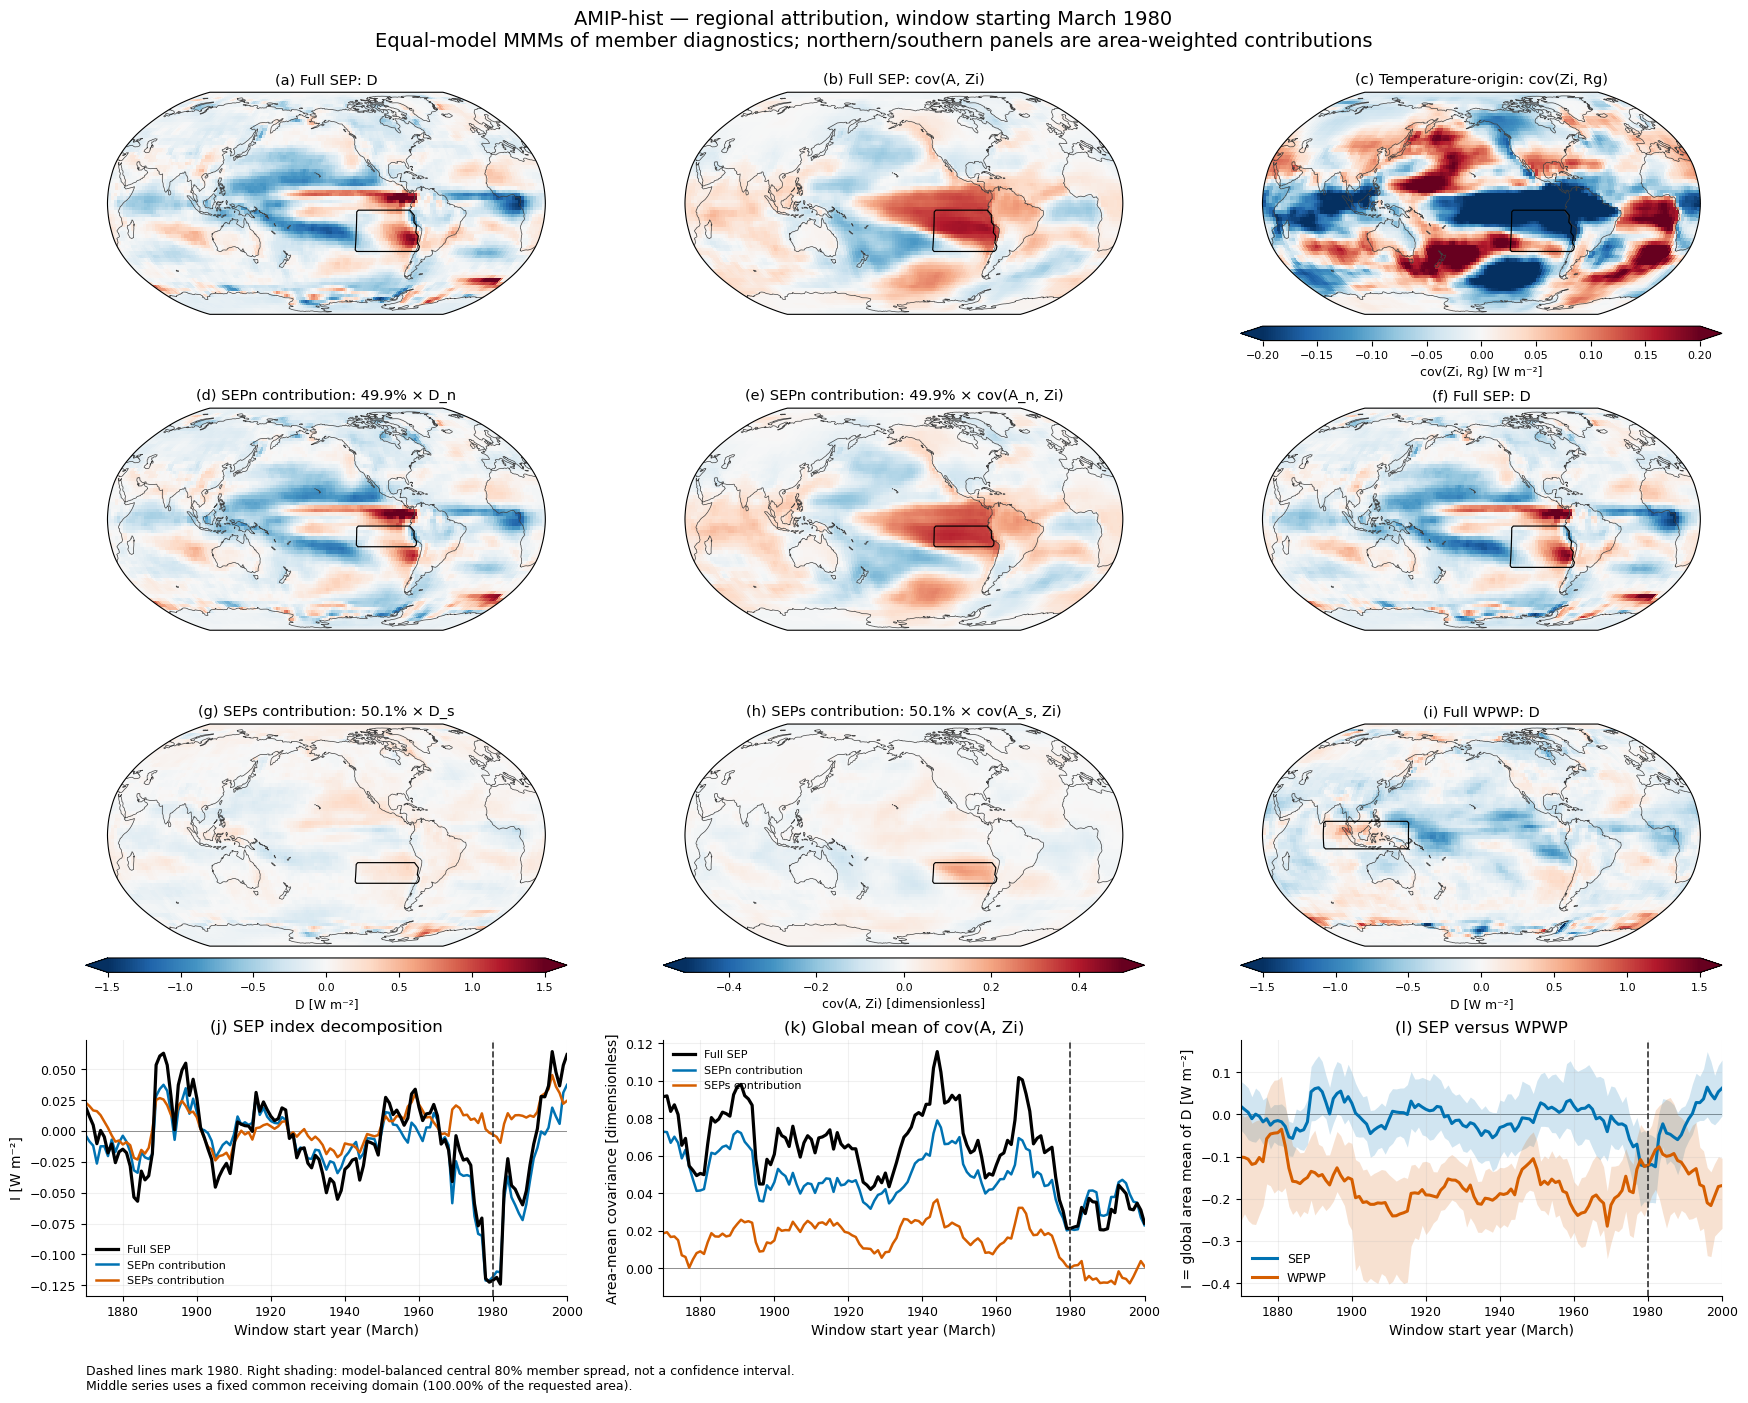

In [6]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1980
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()


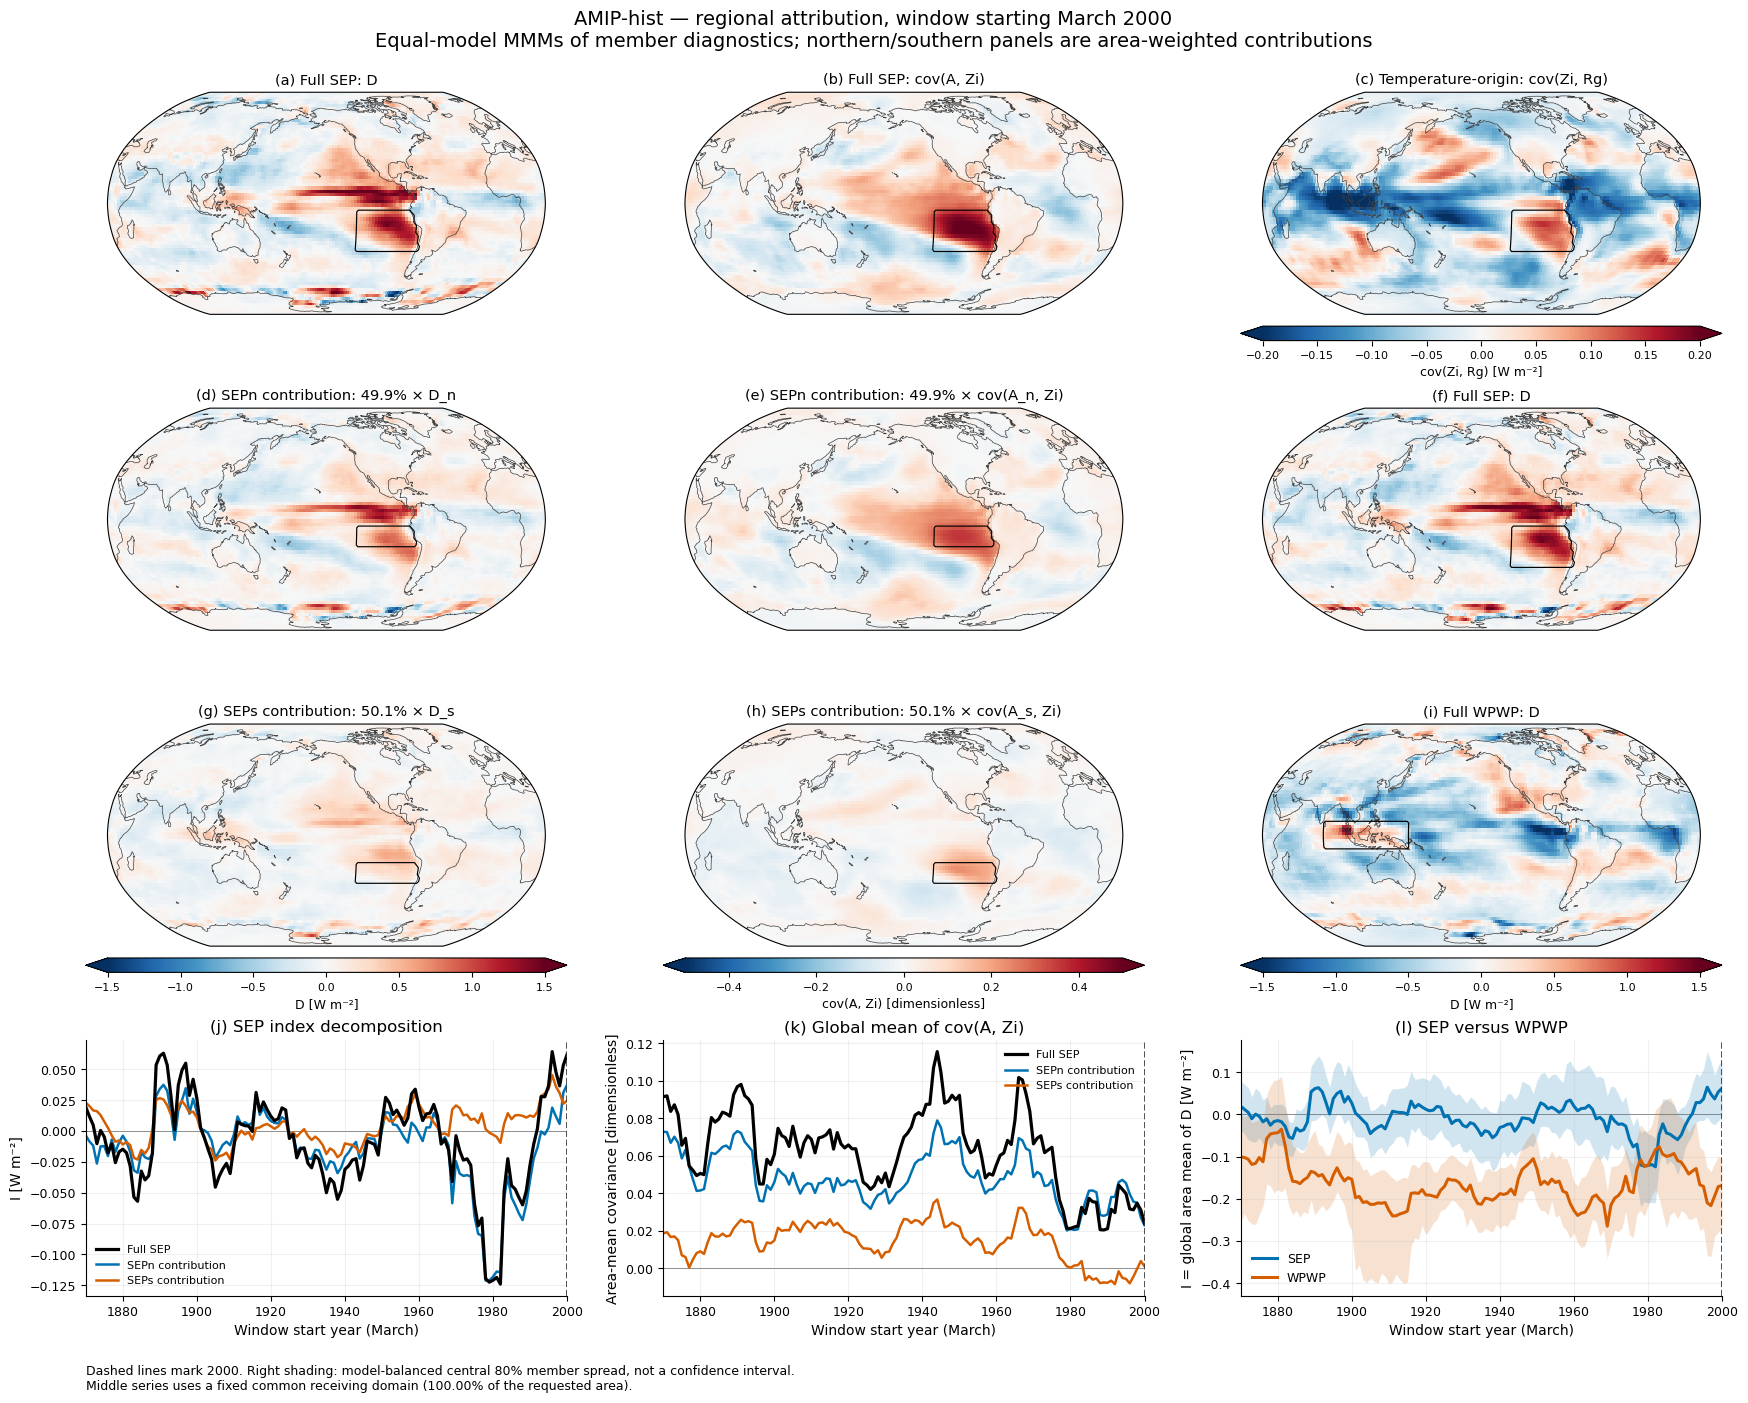

In [7]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 2000
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()


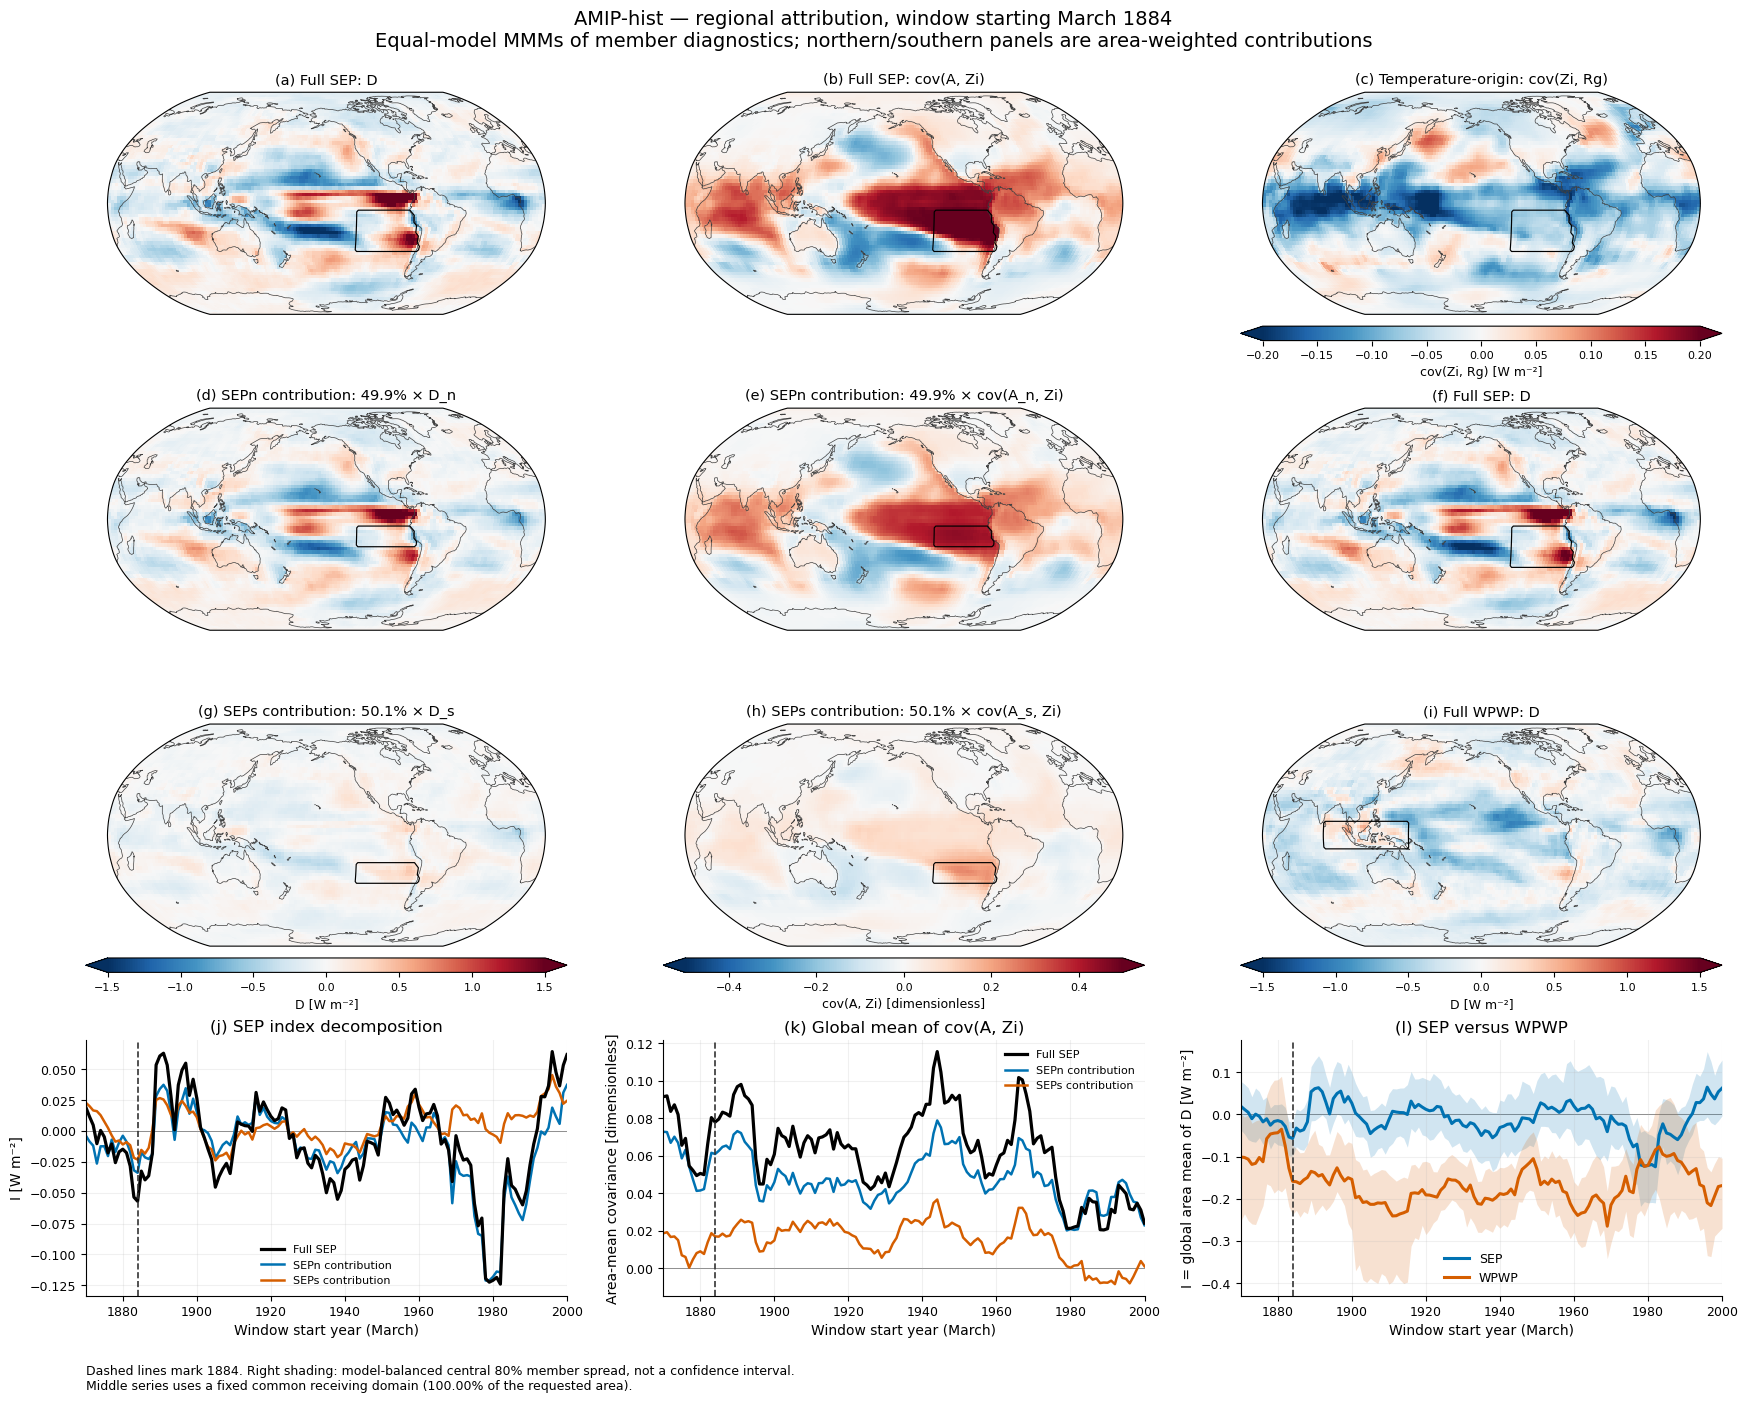

In [8]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1884
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()


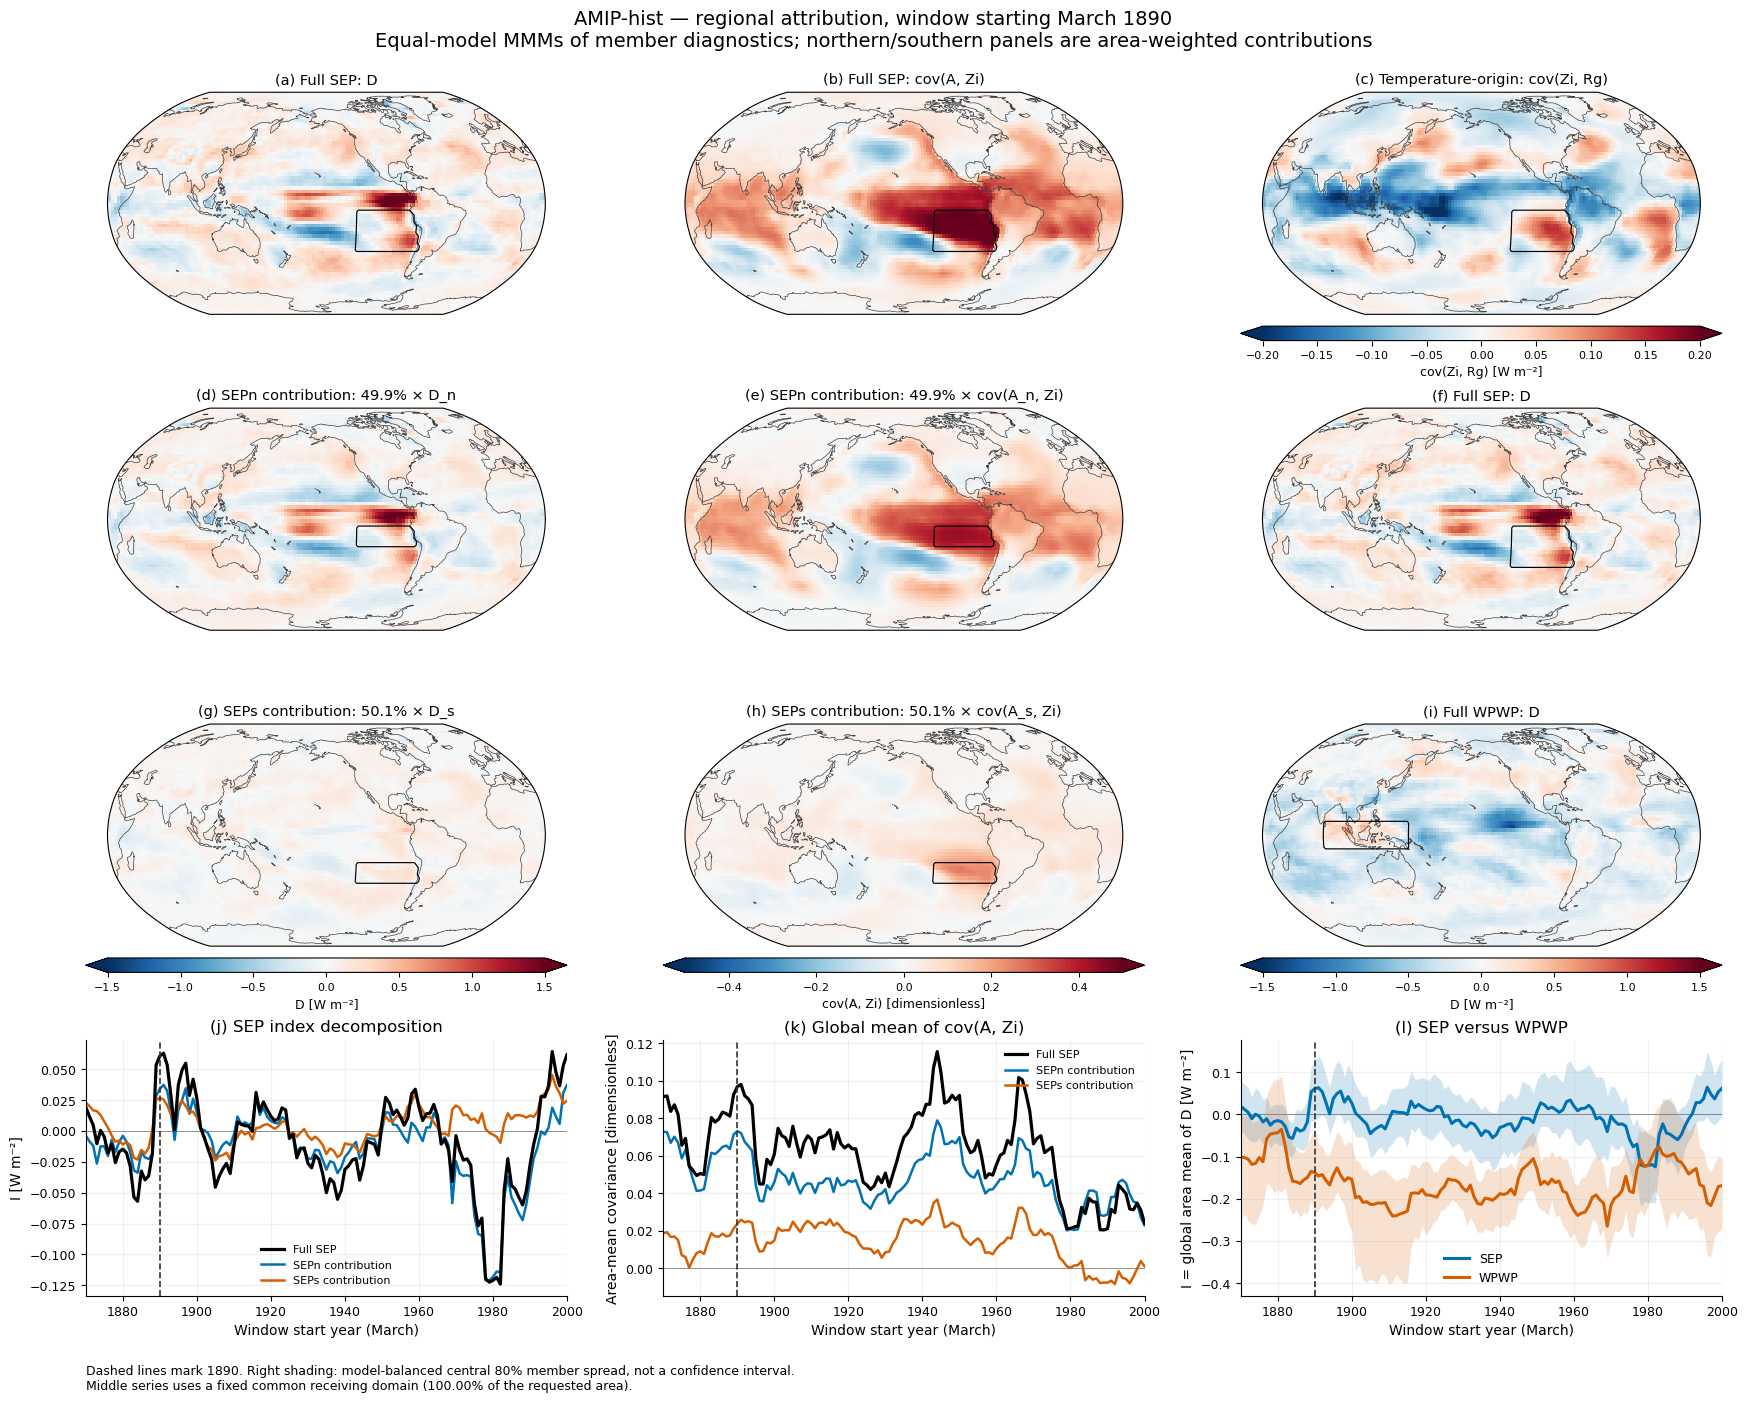

In [9]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1890
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()

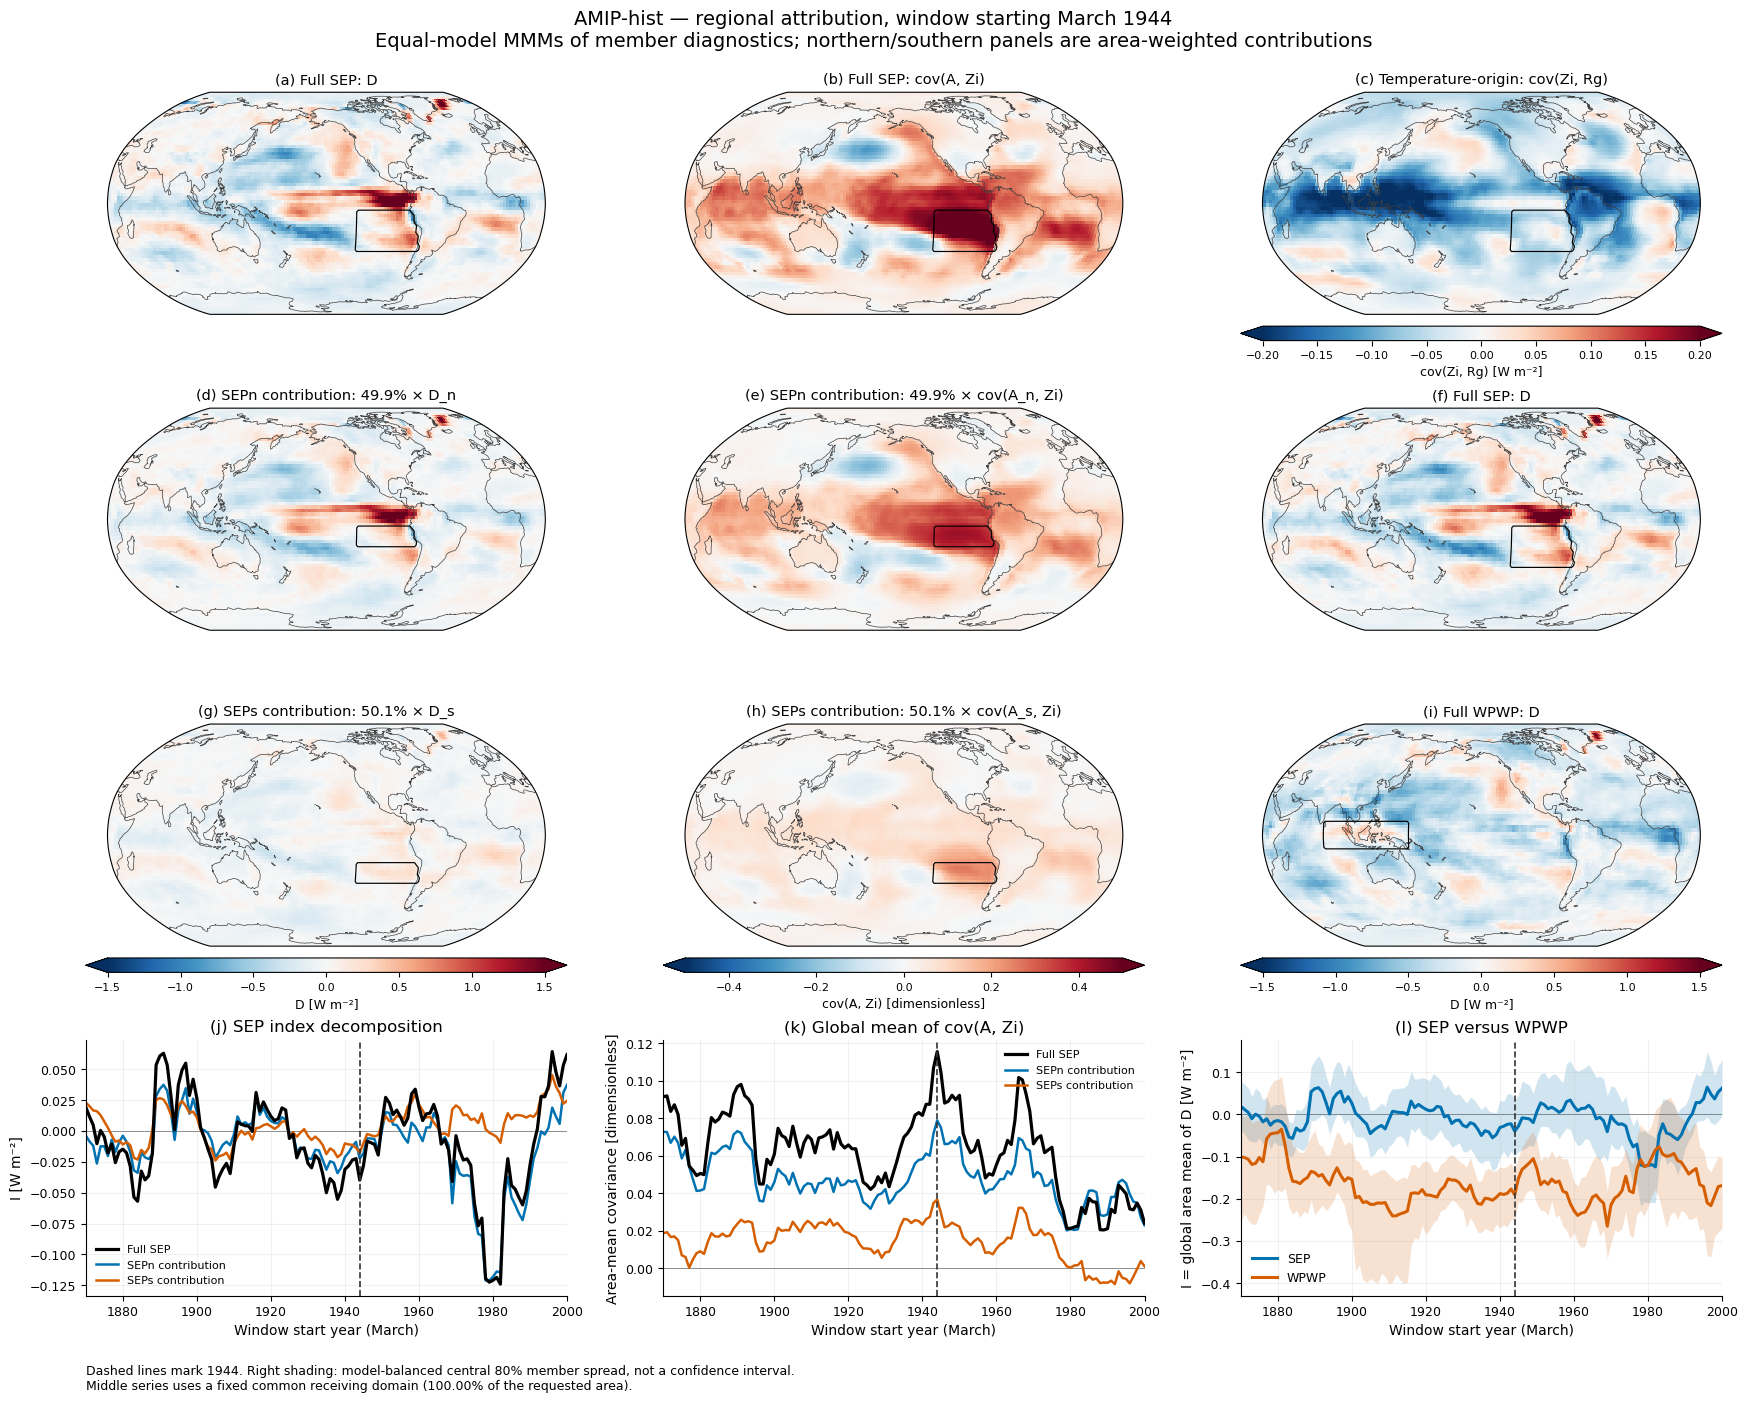

In [11]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1944
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()

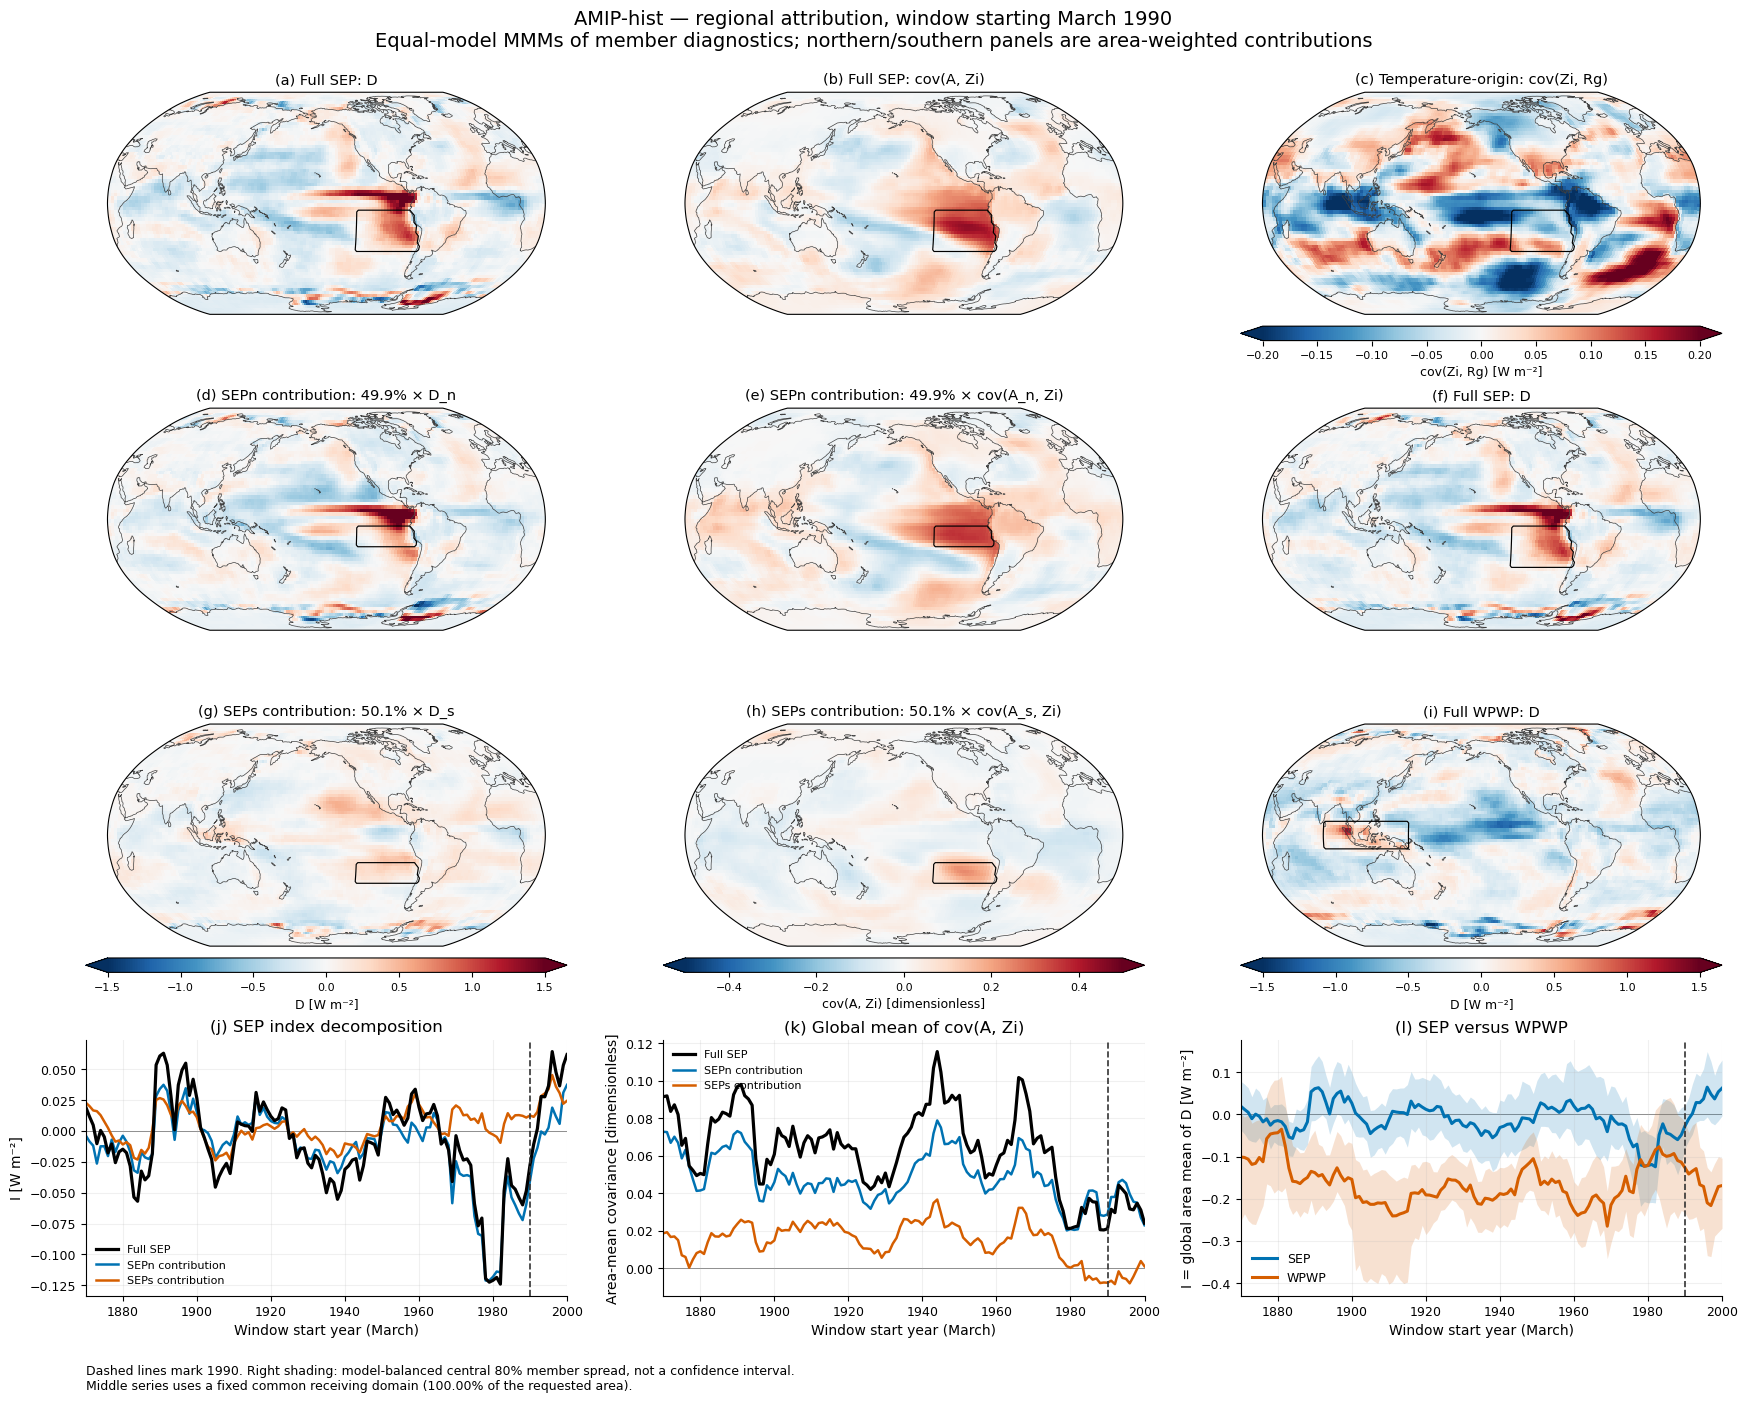

In [12]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1990
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()

In [13]:
# %% 3. Load/prepare once per experiment (no raw temperature/radiation calculations)
overview_run_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/four_region_attribution/run_01")
overview_experiment = "historical_matched"    # Or historical_matched / historical if saved.
overview_catalog = np.load(overview_run_dir/"catalog.npy", allow_pickle=True).item()
overview_series_archive = np.load(overview_run_dir/overview_catalog["series_file"], allow_pickle=True).item()

# The middle time series defaults to the GLOBAL area mean of cov_A_Zi. To
# restrict the RECEIVING cells (while retaining the same source regions/maps),
# set receiving_mask=overview_catalog['regions']['SEP'], receiving_label='Within-SEP'.
overview_data = prepare_region_overview(overview_catalog, overview_series_archive, overview_run_dir,
    experiment=overview_experiment, central_fraction=.8, receiving_mask=None, receiving_label="Global")

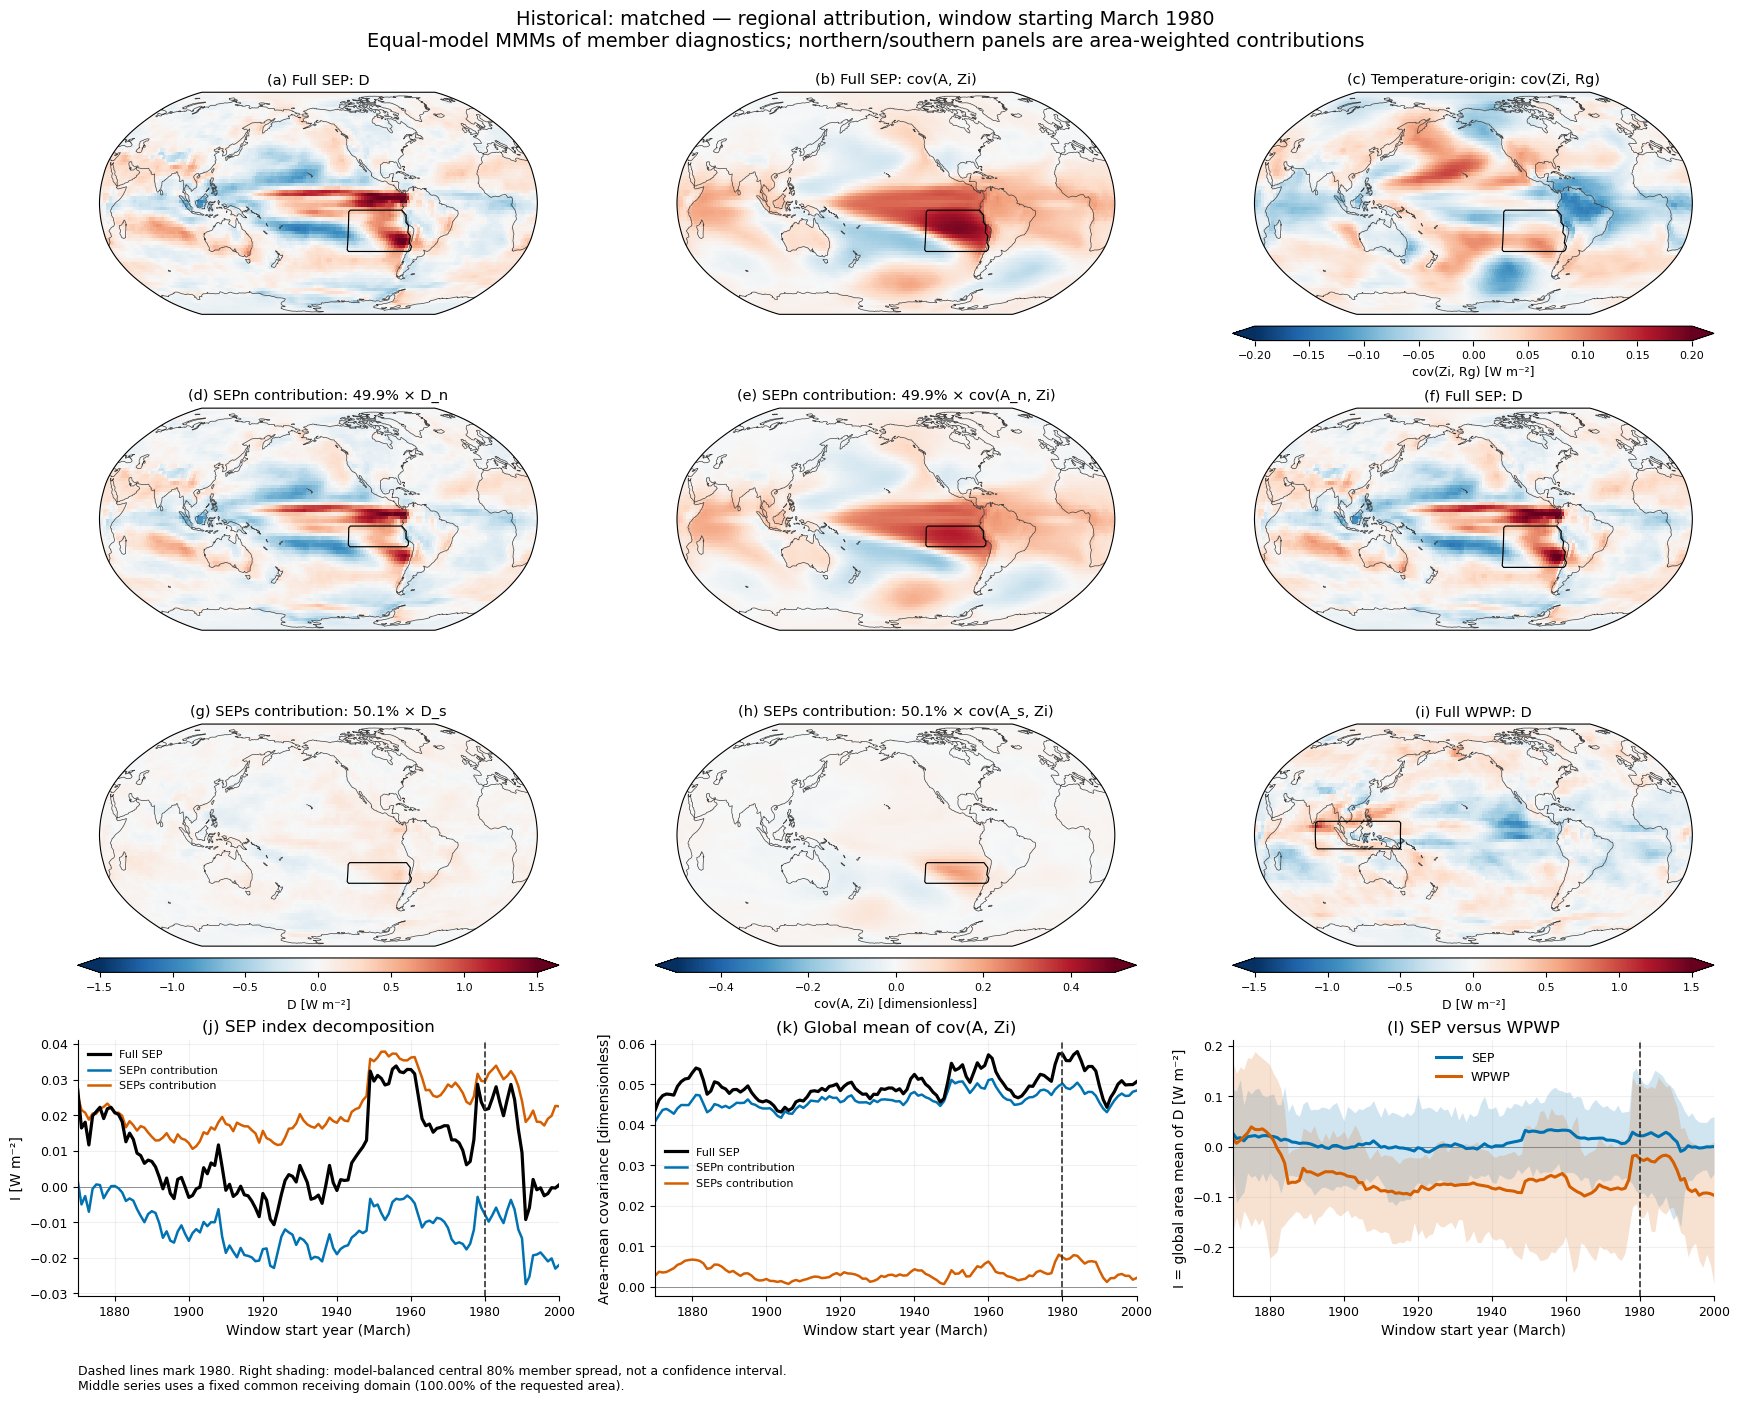

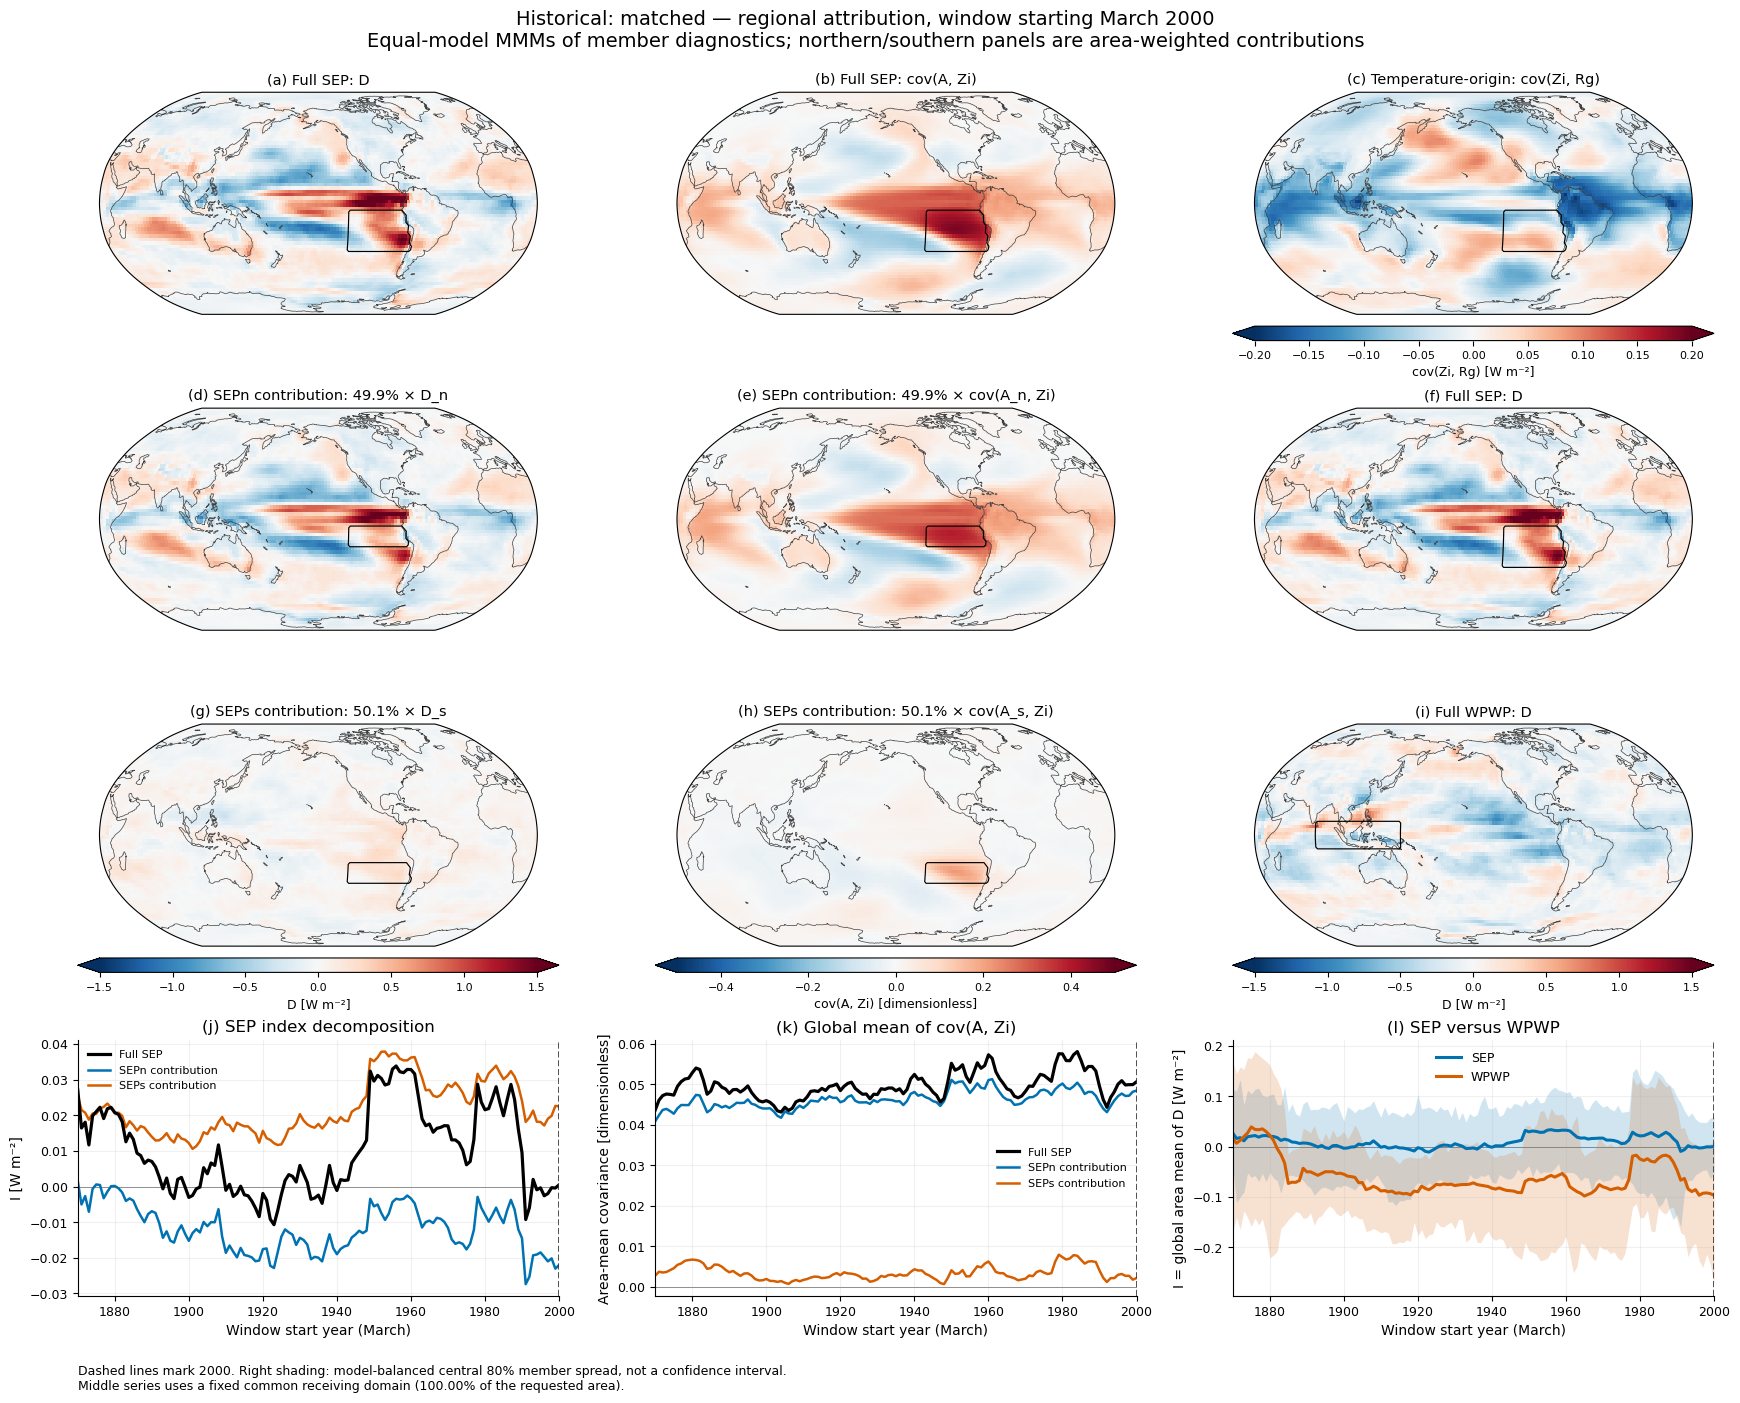

In [17]:
# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 1980
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()

# %% 4. Change the year and rerun just this cell to make another figure
overview_year = 2000
overview_save = True
overview_path = overview_run_dir/f"figures/custom_overview_{overview_experiment}_{overview_year}.png" if overview_save else None
fig_overview, axes_overview, overview_plotted = plot_region_overview(overview_data, start_year=overview_year,
    D_vlim=1.5, C_vlim=.5, ZiR_vlim=.2, central_longitude=210,
    show_full_member_range=False, savepath=overview_path)
plt.show()